# End-to-End Machine Learning Project

The main steps you will go through in this course and your projects are: 

1. ~~Look at the big picture.~~
2. ~~Get the data.~~
3. ~~Discover and visualize the data to gain insights.~~
4. Prepare the data for Machine Learning algorithms.
5. Select a model and train it. 
6. Fine-tune your model. 
7. Present your solution. 
8. Launch, monitor, and maintain your system.

---

# Preparing the Data for ML Algorithms

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

Loading the data:

In [2]:
# Load the housing dataset from a CSV file into a Pandas DataFrame
housing = pd.read_csv('datasets\\housing.csv')

# Adding new engineered features to enhance the dataset

# Calculate the average number of rooms per household
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']  

# Calculate the proportion of bedrooms to total rooms
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']  

# Calculate the average number of people per household
housing['population_per_household'] = housing['population'] / housing['households']  


Partition the data into train and test sets. In this scenario, we are using stratified partition based on the most predictive feature (median income).

In [3]:
# Categorizing median income into discrete income categories

# The `pd.cut` function is used to divide the 'median_income' column into bins.
income_cat = pd.cut(housing['median_income'],  
                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],  # Define bin edges (income ranges)
                    labels=[1, 2, 3, 4, 5])  # Assign category labels (1 to 5)

# Explanation of the bins:
# - 0 to 1.5 -> Category 1 (Low income)
# - 1.5 to 3.0 -> Category 2
# - 3.0 to 4.5 -> Category 3
# - 4.5 to 6.0 -> Category 4
# - 6.0 and above -> Category 5 (High income)

# This transformation helps group households into meaningful income brackets for analysis.


In [4]:
# Splitting the dataset into training and test sets while maintaining the income category distribution

train_set, test_set, income_cat_train, income_cat_test = train_test_split(
    housing,  # The dataset to split
    income_cat,  # The target variable for stratification
    test_size=0.2,  # 20% of the data will be allocated to the test set
    shuffle=True,  # Shuffle the data before splitting
    random_state=42,  # Set a random seed for reproducibility
    stratify=income_cat  # Ensure that the income category distribution is preserved in both sets
)

# Explanation:
# - `train_test_split` randomly splits the dataset into training and testing subsets.
# - `stratify=income_cat` ensures that the proportion of each income category remains the same in both train and test sets.
# - This helps prevent the model from being biased toward certain income levels due to an imbalanced dataset.


Creating variable names for features and target labels in both train and test sets.

In [5]:
# Extracting the target variable (median house value) from the training set
t_train = train_set['median_house_value'].copy()  

# Creating the feature set by dropping the target variable from the training set
X_train = train_set.drop(labels='median_house_value', axis=1)  

# Displaying the shapes of the target and feature sets
t_train.shape, X_train.shape  

# Explanation:
# - `t_train` contains only the target variable (house prices).
# - `X_train` contains all other features except 'median_house_value'.
# - `.copy()` ensures that modifying `t_train` does not affect the original dataset.
# - `shape` provides the number of rows and columns in each dataset.


((16512,), (16512, 12))

In [6]:
t_test = test_set['median_house_value'].copy()
X_test = test_set.drop(labels='median_house_value', axis=1)

t_test.shape, X_test.shape

((4128,), (4128, 12))

## Feature Scaling

One of the most important transformations you need to apply to your data is feature scaling. With few exceptions, Machine Learning algorithms don't perform well when the input numerical attributes have very different scales. 

* Note that scaling the target values is generally **not** required. 

There are two common ways to get all attributes to have the same scale: 

1. **Min-Max Scaling**. Values are shifted and rescaled so that they end up ranging from 0 to 1.
    * Highly affected by outliers.
    

2. **Standardization**. First it subtracts the mean value (so standardized values always have a zero mean), and then it divides by the standard deviation so that the resulting distribution has unit variance.
    * Less affected by outliers
    * Gaussianity assumptions

<div class="alert alert-warning" role="alert">
    
As with all the transformations, it is important to fit the scalers to the training data only, not to the full dataset (including the test set). Only then can you use them to transform the training set and the test set (and new data).
</div>

## Transformation Pipelines

Creating a ```scikit-learn``` transformation pipeline to scale and encode numerical and categorical features.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [8]:
# Identifying feature types in the dataset

# Extracting numerical attributes by excluding the categorical feature 'ocean_proximity'
num_attribs = np.setdiff1d(X_train.columns, ['ocean_proximity'])  

# Defining categorical attributes
cat_attribs = ['ocean_proximity']  

# Creating a pipeline for preprocessing numerical attributes
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values by replacing with the median
    ('std_scaler', StandardScaler())  # Standardize numerical features (zero mean, unit variance)
])

# Creating a ColumnTransformer for preprocessing both numerical and categorical attributes
preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),  # Apply the numerical pipeline to numerical features
    ('cat', OneHotEncoder(), cat_attribs)  # Apply OneHotEncoding to categorical features
])

# Explanation:
# - `num_pipeline` ensures that numerical features are imputed (filled with the median where missing)
#   and standardized for better model performance.
# - `ColumnTransformer` applies different preprocessing steps to numerical and categorical features
#   in a single transformation step.
# - `OneHotEncoder()` converts categorical variables into binary columns, making them usable for models.

# Display the preprocessing pipeline
preprocessing


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('std_scaler',
                                                  StandardScaler())]),
                                 array(['bedrooms_per_room', 'households', 'housing_median_age',
       'latitude', 'longitude', 'median_income', 'population',
       'population_per_household', 'rooms_per_household',
       'total_bedrooms', 'total_rooms'], dtype=object)),
                                ('cat', OneHotEncoder(), ['ocean_proximity'])])

In [9]:
# Applying the preprocessing pipeline to the training set
X_train_prepared = preprocessing.fit_transform(X_train)  

# Transforming the test set using the already fitted preprocessing pipeline
X_test_prepared = preprocessing.transform(X_test)  

# Important Note:
# - `fit_transform(X_train)`: Fits the preprocessing pipeline to the training data and transforms it.
# - `transform(X_test)`: Transforms the test data using the pipeline fitted on the training data.
# - We **never** use `fit_transform` or `fit` on the test set to prevent data leakage.
# - This ensures that the test set remains a completely unseen dataset for model evaluation.


In [10]:
X_train_prepared.shape, X_test_prepared.shape

((16512, 16), (4128, 16))

In [11]:
# Creating attribute labels for the processed dataset

attribute_labels = np.hstack((
    num_attribs,  # Numerical feature names remain unchanged
    preprocessing.named_transformers_['cat'].categories_[0]  # Extract category names from the OneHotEncoder
))

# Explanation:
# - `num_attribs` contains the names of numerical features.
# - `preprocessing.named_transformers_['cat'].categories_[0]` retrieves the categories of the categorical feature
#   ('ocean_proximity') after OneHotEncoding.
# - `np.hstack(...)` horizontally stacks numerical and categorical feature names into a single array.
# - This is useful for understanding the transformed dataset and mapping the encoded features back to their original attributes.

# Display the attribute labels
attribute_labels


array(['bedrooms_per_room', 'households', 'housing_median_age',
       'latitude', 'longitude', 'median_income', 'population',
       'population_per_household', 'rooms_per_household',
       'total_bedrooms', 'total_rooms', '<1H OCEAN', 'INLAND', 'ISLAND',
       'NEAR BAY', 'NEAR OCEAN'], dtype=object)

In [12]:
# Converting the transformed training data into a Pandas DataFrame for better visualization and analysis

housing_train_prepared = pd.DataFrame(
    X_train_prepared,  # The preprocessed numerical and encoded categorical features
    columns=attribute_labels,  # Assign meaningful column names using `attribute_labels`
    index=train_set.index  # Maintain the original index from the training set
)

# Explanation:
# - `X_train_prepared` is originally a NumPy array after transformation.
# - Converting it into a DataFrame makes it easier to inspect and analyze.
# - Column names (`attribute_labels`) ensure that each transformed feature remains interpretable.
# - Keeping the original `train_set.index` preserves dataset alignment.

# Display the processed training data
housing_train_prepared


,bedrooms_per_room,households,housing_median_age,latitude,longitude,median_income,population,population_per_household,rooms_per_household,total_bedrooms,total_rooms,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-0.122484,0.556286,0.027564,1.347438,-0.941350,-0.893647,0.732602,0.006223,0.017395,0.640371,0.584777,0.0,1.0,0.0,0.0,0.0
15502,-0.911663,0.721318,-1.722018,-1.192440,1.171782,1.292168,0.533612,-0.040811,0.569256,0.781561,1.261467,0.0,0.0,0.0,0.0,1.0
2908,-0.370939,-0.524407,1.220460,-0.125972,0.267581,-0.525434,-0.674675,-0.075371,-0.018024,-0.545138,-0.469773,0.0,1.0,0.0,0.0,0.0
14053,1.115873,-0.037297,-0.370069,-1.351474,1.221738,-0.865929,-0.467617,-0.106803,-0.595140,-0.036367,-0.348652,0.0,0.0,0.0,0.0,1.0
20496,-0.526821,0.220898,-0.131489,-0.635818,0.437431,0.325752,0.374060,0.006109,0.251241,0.272790,0.427179,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-0.491732,1.341519,-1.165333,-1.220505,1.251711,0.637374,0.543471,-0.092580,0.466353,1.696862,1.890456,1.0,0.0,0.0,0.0,0.0
12661,-0.574363,2.451492,-1.085806,1.342761,-0.921368,-0.557509,3.002174,0.023024,0.050362,2.161816,2.468471,0.0,1.0,0.0,0.0,0.0
19263,0.385514,-0.865118,1.538566,1.310018,-1.570794,-0.365475,-0.862013,-0.037436,-0.509240,-0.895679,-0.895802,1.0,0.0,0.0,0.0,0.0
19140,-0.506808,0.010616,-1.165333,1.249211,-1.560803,0.168261,-0.189747,-0.059156,0.328149,0.112126,0.249005,1.0,0.0,0.0,0.0,0.0


This is the **feature matrix**, the input data used to train a machine learning model.

In [13]:
housing_test_prepared = pd.DataFrame(X_test_prepared,
                                     columns=attribute_labels,
                                     index=test_set.index)

housing_test_prepared

,bedrooms_per_room,households,housing_median_age,latitude,longitude,median_income,population,population_per_household,rooms_per_household,total_bedrooms,total_rooms,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
5241,-0.977188,1.232385,0.027564,-0.710658,0.592294,2.312866,0.685096,-0.070911,0.488287,1.163748,1.788508,1.0,0.0,0.0,0.0,0.0
17352,-1.064600,-0.569658,-0.370069,-0.350491,-0.421810,0.595324,-0.506160,-0.006497,0.649943,-0.552441,-0.281778,1.0,0.0,0.0,0.0,0.0
3505,-0.472011,-0.590952,0.584248,-0.649851,0.562321,0.266693,-0.548289,-0.013664,-0.060028,-0.642511,-0.546935,1.0,0.0,0.0,0.0,0.0
7777,-0.283078,-0.521745,0.504722,-0.808885,0.737166,-0.317651,-0.311651,0.040139,0.019639,-0.508624,-0.453405,1.0,0.0,0.0,0.0,0.0
14155,-0.880800,0.311400,0.743301,-1.342119,1.251711,0.250419,0.067507,-0.057112,0.273515,0.194892,0.540818,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12182,-0.399795,-0.343404,-0.767701,-0.897758,1.141809,-0.555882,-0.190643,0.015833,0.255891,-0.260324,-0.175153,1.0,0.0,0.0,0.0,0.0
7275,2.091170,-0.572320,0.345669,-0.771465,0.667228,-0.899999,-0.134173,0.121462,-0.881488,-0.584087,-0.812560,1.0,0.0,0.0,0.0,0.0
17223,-0.363368,-0.370022,1.140933,-0.560978,-0.072119,0.432636,-0.678261,-0.107429,-0.178260,-0.467240,-0.393546,1.0,0.0,0.0,0.0,0.0
10786,-0.242358,-0.226285,0.107090,-0.939855,0.832082,0.544192,-0.303584,-0.040803,-0.158410,-0.296839,-0.257927,1.0,0.0,0.0,0.0,0.0


In [14]:
t_train
# generally do not scale the target values for regression tasks
# but we in some cases we want to scale/encode the target 
# values for classification tasks

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
           ...   
15174    268500.0
12661     90400.0
19263    140400.0
19140    258100.0
19773     62700.0
Name: median_house_value, Length: 16512, dtype: float64

---

# Step 5: Select and Train a Model - Linear Regression

Let's start by using a simple **multiple linear regression** where the goal is to predict a single (continuous) outcome using several explanatory attributes/features.

The **mapper** function takes the form:

\begin{align*}
y = w_0 + w_1 f_1 + w_2 f_2 + \dots + w_M + f_M = w_0 + \sum_{i=1}^M w_i f_i
\end{align*}

where $f_i$ is the $i$-th attribute (or feature), $w_i$ the associated weight parameter and $w_0$ corresponds to the bias term in the multiple linear regression model.

In [15]:
# Import the Linear Regression model from scikit-learn
from sklearn.linear_model import LinearRegression  

# Linear Regression assumes the Mean Squared Error (MSE) as the objective function by default

# Initializing the Linear Regression model
lin_reg = LinearRegression()  

# Training (fitting) the model using the preprocessed training data
# - `X_train_prepared`: Feature matrix after preprocessing
# - `t_train`: Target variable (median house value)
lin_reg.fit(X_train_prepared, t_train)  

# Explanation:
# - Linear Regression is a **supervised learning** algorithm, meaning it learns from labeled data.
# - The `fit` function takes input features (`X_train_prepared`) and their corresponding target values (`t_train`).
# - The model learns the best-fit linear relationship between the features and the target variable.


LinearRegression()

In [16]:
# parameters w
lin_reg.coef_, lin_reg.coef_.shape

(array([ 16859.18615554,  42894.50706978,  13931.56938783, -56657.82876645,
        -56046.33896677,  78265.15994713, -46114.16368891,    913.38798131,
          7278.00685102,    322.80384089,   7996.0630126 , -17551.72508026,
        -51777.57825901, 105745.06664576, -22255.10163102, -14160.66167547]),
 (16,))

In [17]:
# intercept or bias term, w0

lin_reg.intercept_

np.float64(235539.02199526783)

In [18]:
# concatenating all parameters into vector w

w = np.vstack((lin_reg.intercept_, lin_reg.coef_[:,np.newaxis]))
w

array([[235539.02199527],
       [ 16859.18615554],
       [ 42894.50706978],
       [ 13931.56938783],
       [-56657.82876645],
       [-56046.33896677],
       [ 78265.15994713],
       [-46114.16368891],
       [   913.38798131],
       [  7278.00685102],
       [   322.80384089],
       [  7996.0630126 ],
       [-17551.72508026],
       [-51777.57825901],
       [105745.06664576],
       [-22255.10163102],
       [-14160.66167547]])

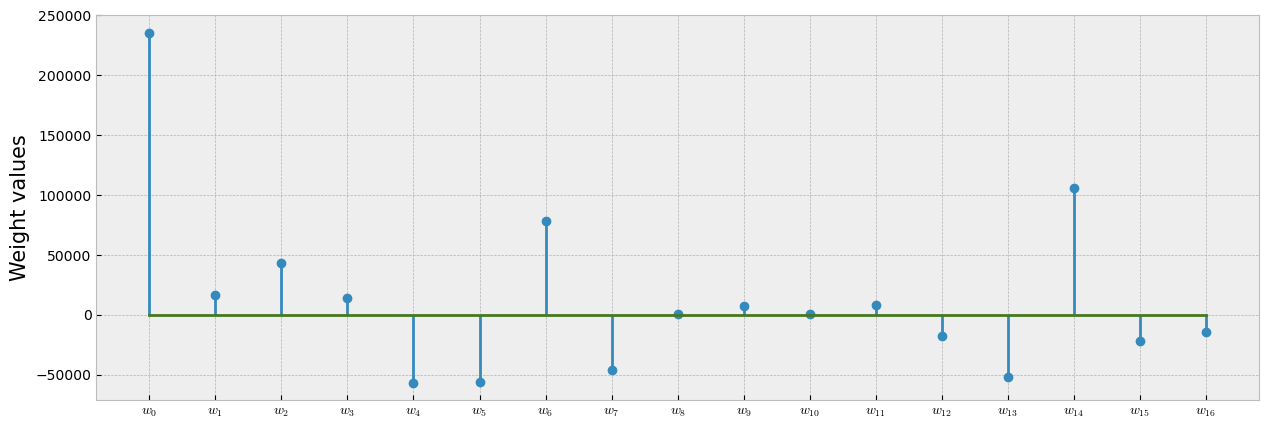

In [19]:
plt.figure(figsize=(15,5))
plt.stem(w)
plt.ylabel('Weight values', size=15)
plt.xticks(np.arange(len(w)), ['$w_{'+str(i)+'}$' for i in range(len(w))],rotation=0);

Alternatively, you can create a single pipeline to include preprocessing and the ML algorithm:

In [20]:
preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('std_scaler',
                                                  StandardScaler())]),
                                 array(['bedrooms_per_room', 'households', 'housing_median_age',
       'latitude', 'longitude', 'median_income', 'population',
       'population_per_household', 'rooms_per_household',
       'total_bedrooms', 'total_rooms'], dtype=object)),
                                ('cat', OneHotEncoder(), ['ocean_proximity'])])

In [21]:
# Define pipeline
model = Pipeline([('preprocess', preprocessing),
                 ('lin_reg', LinearRegression())])
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  array(['bedrooms_per_room', 'households', 'housing_median_age',
       'latitude', 'longitude', 'median_income', 'population',
       'population_per_household', 'rooms_per_household',
       'total_bedrooms', 'total_rooms'], dtype=object)),
                                                 ('cat', OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('lin_reg', LinearRegression())])

In [22]:
# Train pipeline

model.fit(X_train, t_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  array(['bedrooms_per_room', 'households', 'housing_median_age',
       'latitude', 'longitude', 'median_income', 'population',
       'population_per_household', 'rooms_per_household',
       'total_bedrooms', 'total_rooms'], dtype=object)),
                                                 ('cat', OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('lin_reg', LinearRegression())])

In [23]:
## Accessing the model parameters

model.named_steps.lin_reg.intercept_, model.named_steps.lin_reg.coef_

(np.float64(235539.02199526783),
 array([ 16859.18615554,  42894.50706978,  13931.56938783, -56657.82876645,
        -56046.33896677,  78265.15994713, -46114.16368891,    913.38798131,
          7278.00685102,    322.80384089,   7996.0630126 , -17551.72508026,
        -51777.57825901, 105745.06664576, -22255.10163102, -14160.66167547]))

In [24]:
# Making model predictions

y_train = model.predict(X_train)

y_train.shape

(16512,)

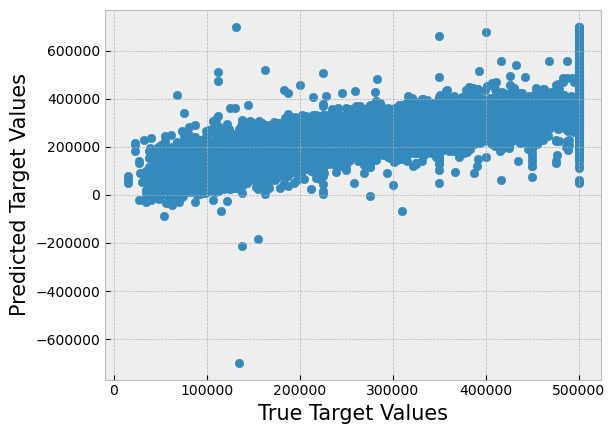

In [25]:
# Display predictions

plt.scatter(t_train, y_train)
plt.xlabel('True Target Values', size=15)
plt.ylabel('Predicted Target Values', size=15);

We should summarize this information using quantitative performance measures. Examples include:

* Coefficient of determination ($r^2$) of the quantile-quantile (Q-Q) plot,
* Root Mean Squared Error (RMSE),
* Root Mean Absolute Error (RMAE),
* and others...

### Other Performance Measures - In Practice

Performance of an algorithm can be determined using a variety of statistical goodness-of-fit measures. 

* For regression tasks this includes error-based measurements, hypothesis tests, Q-Q plots.
* For classification tasks this includes error rate, accuracy, ROC curves, performance-recall curves.

But it can also be in terms of:
1. Risk,
2. Training time,
3. Training storage/memory,
4. Testing time,
5. Testing storage/memory,
6. Interpretability, namely, whether the method allows knowledge extraction which can be checked and validated by experts, and
7. computational complexity.

---

```Scikit-Learn```'s API documentation offers a few performance measures for regression tasks: [https://scikit-learn.org/stable/modules/classes.html#regression-metrics](https://scikit-learn.org/stable/modules/classes.html#regression-metrics).

In [26]:
# Import the mean squared error (MSE) metric from scikit-learn
from sklearn.metrics import mean_squared_error  

# Predict target values for the training set using the trained Linear Regression model
y_train = lin_reg.predict(X_train_prepared)  

# Compute the Mean Squared Error (MSE) between actual and predicted values
mse_train = mean_squared_error(t_train, y_train)  

# Compute the Root Mean Squared Error (RMSE) to interpret the error in original units
rmse_train = np.sqrt(mse_train)  

# Display the RMSE for the training set
print('RMSE Training Set: ', rmse_train)  

# Explanation:
# - `mean_squared_error(t_train, y_train)`: Computes the average squared differences between actual (`t_train`)
#   and predicted (`y_train`) values.
# - Taking the square root of MSE gives RMSE, which is in the same unit as the target variable (`median_house_value`).
# - RMSE measures how well the model fits the training data—lower values indicate better fit.


RMSE Training Set:  68160.92435491859


This is clearly not a good score. When this happens it can mean that the features do not provide enough information to make good predictions, or that the model is not powerful enough. 

The main ways to fix underfitting are to select a more powerful model, to feed the training algorithm with better features, or to reduce the constraints on the model. 

This model is not regularized, which rules out the last option. You could try to add more features but let's start with a more complex model.

In [27]:
from sklearn.tree import DecisionTreeRegressor 

# Define pipeline
model2 = Pipeline([('preprocess', preprocessing),
                  ('dec_tree', DecisionTreeRegressor())])

# Train pipeline
model2.fit(X_train, t_train)

# Make model predictions
y_train = model2.predict(X_train)
y_test = model2.predict(X_test)

In [28]:
# Evaluate performance
mse_train = mean_squared_error(t_train, y_train)
rmse_train = np.sqrt(mse_train)

print('RMSE Training Set: ', rmse_train)

RMSE Training Set:  0.0


Suspiciously optimistically! 

Since we should not touch the test data until we have finalized model selection, what should we do?

* We need to use part of the training set for training and part of it for model validation. This is known as **cross-validation**.

---

# Experimental Design

<div class="alert alert-info">
    <b>Experimental Design - How to use your data without cheating</b> 

In experimental design we need data to train (learn) models, and to test how good the models are. The training data needs to be different (disjoint) from the test data. Otherwise we would be testing the learned model on data it had previously seen, and we would get a biased estimate of the model's generalized performance.
    
Most machine learning algorithms require choosing parameter values (**hyperparemeters**); very often this is done by setting aside some of the training data to evaluate the quality of different parameter settings.
</div>

## Cross-Validation

The goal of **cross-validation**, or CV, is to test the model's ability to predict new data that was not used in estimating the model, in order to flag problems like overfitting or selection bias and to give an insight on how the model will generalize to an independent dataset (i.e., an unknown dataset).

Cross-validation allows us to determine the values for the hyperparameter that provide the most **generalization**. Cross-validation mitigates the occurrence of **overfitting**, but it does not eliminate it entirely.

Let's consider the **MSE** as our performance measure. There are different strategies for implementing cross-validation:

1. **k-fold cross-validation**. Training set is partitioned into $k$ folds.
2. **Leave-One-Out cross-validation**. Extreme case, where only one sample is left for validation.
3. **Stratified cross-validation**. Data is partition such that each class prior probability is preserved.
4. **$k\times 2$ cross-validation**. Training data is partitioned into 2 sets of equal size $k$ times.

### K-Fold Cross-Validation

The technique of k-fold cross-validation, illustrated below for the case of $k=4$, involves taking the available data and partitioning it into $k$ groups (in the simplest case these are of equal size). Then $k-1$ of the groups are used to train a set of models that are then evaluated on the remaining group. This procedure is then repeated for all $k$ possible choices for the held-out group, indicated in the picture below by the red blocks, and the performance scores from the runs are then averaged.

$K$ is typically 10 or 30. As $K$ increases, the percentage of training instances increases and we get more robust estimators, but the validation set becomes smaller. Furthermore, there is the cost of training the classiﬁer $K$ times, which increases as $K$ is increased. As $N$ increases, $K$ can be smaller; if $N$ is small, $K$ should be large to allow large enough training sets.

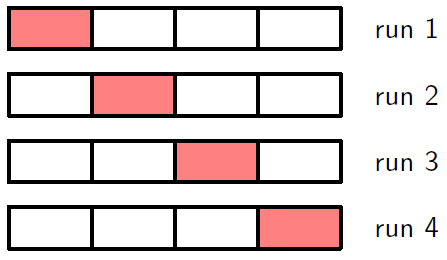

In [29]:
from IPython.display import Image
Image('figures\\Kfold CV.png',width=400)

The following code randomly splits the training set into 10 distinct subsets called **folds**, then it trains and evaluates the model 10 times, picking a different fold for evaluation every time and training on the other 9 folds. 

The result is an array containing the 10 evaluation scores:

In [30]:
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import KFold

cross_val_score?

In [31]:
scores = cross_val_score(model2,
                        X_train,
                        t_train,
                        scoring='neg_mean_squared_error',
                        cv=KFold(10, random_state=0, shuffle=True))

# cross_val_score it searches for the value that MAXIMIZES the scoring function.

Find more ```scoring``` metrics in the ```scikit-learn``` API [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html).

In [32]:
scores

array([-5.31852770e+09, -5.37294764e+09, -4.42376185e+09, -5.06109587e+09,
       -4.63305216e+09, -4.84380227e+09, -4.73242181e+09, -5.04242304e+09,
       -5.32490911e+09, -4.77784899e+09])

In [33]:
rmse_scores = np.sqrt(-scores)

rmse_scores

array([72928.23665837, 73300.39321071, 66511.36633875, 71141.37941942,
       68066.52746781, 69597.43002044, 68792.59997931, 71010.02072952,
       72971.97482709, 69121.98630209])

```Scikit-Learn```'s cross-validation features expect a utility function (greater is better) rather than a cost function (lower is better), so the scoring function is actually the opposite of the MSE (i.e., a negative value), which is why the preceding code computes ```-scores``` before calculating the square root. 

Let's look at the results:

In [34]:
def display_scores(scores):
    print('Scores:', scores)
    print('Mean:', scores.mean())
    print('Standard deviation:', scores.std())
    
display_scores(rmse_scores)

Scores: [72928.23665837 73300.39321071 66511.36633875 71141.37941942
 68066.52746781 69597.43002044 68792.59997931 71010.02072952
 72971.97482709 69121.98630209]
Mean: 70344.1914953506
Standard deviation: 2184.8953510696556


Let's compute the same scores for the Linear Regression model just to be sure:

In [35]:
lin_reg_scores = cross_val_score(model, # now it uses the linear regression model
                        X_train,
                        t_train,
                        scoring='neg_mean_squared_error',
                        cv=KFold(10, random_state=0, shuffle=True))

# cross_val_score it searches for the value that MAXIMIZES the scoring function.

display_scores(np.sqrt(-lin_reg_scores))

Scores: [69224.31849412 69113.59743973 68092.37193773 66189.10546646
 66609.47956814 64797.7709124  72462.4660725  68294.11170892
 72604.90116056 66613.08557631]
Mean: 68400.12083368798
Standard deviation: 2444.228497244148


Let's try one last model now: the ```RandomForestRegressor```. (We will study this model in detail later on in the course.)

Random Forests work by training many Decision Trees on random subsets of the features, then averaging out their predictions. Building a model on top of many other models is called **Ensemble Learning**, and it is often a great way to push ML algorithms even further.

In [36]:
from sklearn.ensemble import RandomForestRegressor

# Model 3: define pipeline
model3 = Pipeline([('preprocess', preprocessing),
                  ('random_forest', RandomForestRegressor())])

# Train model
model3.fit(X_train, t_train)

# Make model predictions
y_train = model3.predict(X_train)
y_test = model3.predict(X_test)

In [37]:
# Evaluate performance on validation folds
forest_scores = cross_val_score(model3,
                                X_train, 
                                t_train, 
                                scoring='neg_mean_squared_error', 
                                cv=KFold(10, random_state=0, shuffle=True)) 

forest_rmse_scores = np.sqrt(-forest_scores)

display_scores(forest_rmse_scores)

Scores: [54584.06381568 50738.32858607 49660.43793738 48337.15711451
 47584.94350955 48441.38246718 50739.17215463 50997.33094534
 51954.53673234 48904.11070376]
Mean: 50194.14639664356
Standard deviation: 1971.95864389299


Much better!

But, the score on the training set is still much lower than on the validation sets, meaning that the model is **still overfitting the training set**. 

Possible solutions for overfitting are to simplify the model, constrain it (i.e., regularize it), or get a lot more training data. Before you dive much deeper into Random Forests, however, you should try out many other models from various categories of Machine Learning algorithms (e.g., several Support Vector Machines with different kernels, and possibly a neural network), without spending too much time tweaking the hyperparameters. The goal is to shortlist a few (two to five) promising models.

---